Running: {'optimizer_name': 'sgd', 'init_type': 'he', 'regularizer_type': None}
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 786us/step
Running: {'optimizer_name': 'adam', 'init_type': 'he', 'regularizer_type': None}
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step
Running: {'optimizer_name': 'rmsprop', 'init_type': 'he', 'regularizer_type': None}
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step
Running: {'optimizer_name': 'adam', 'init_type': 'he'}
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 992us/step
Running: {'optimizer_name': 'adam', 'init_type': 'xavier'}
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step
Running: {'optimizer_name': 'adam', 'init_type': 'he', 'regularizer_type': 'l1'}
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step
Running: {'optimizer_name': 'adam', 'init_type': 'he', 'regularizer_type': 'l2'}
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step
Running: {'optimizer_name': 'adam', 'init_type': 'he', 'dropout_rate': 0.5}
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step


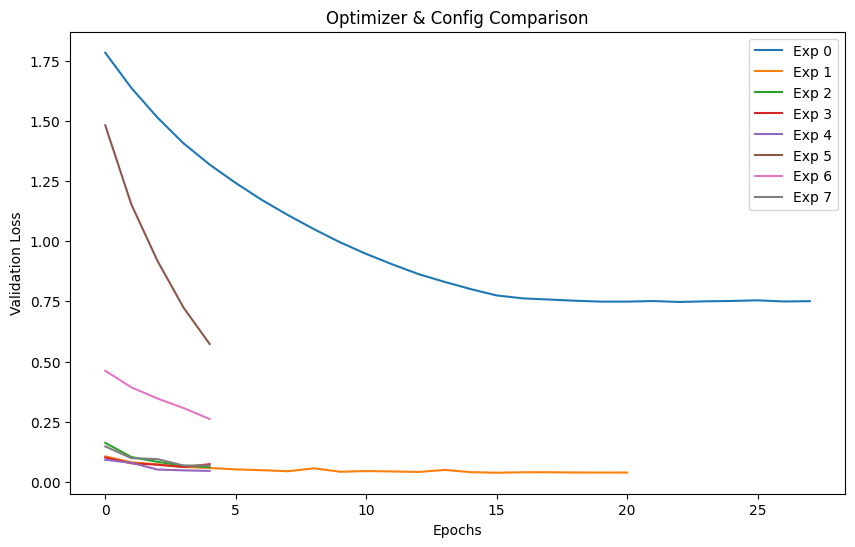


=== FINAL RESULTS ===
                                              config          RMSE  \
1  {'optimizer_name': 'adam', 'init_type': 'he', ...  1.231179e+06   
4  {'optimizer_name': 'adam', 'init_type': 'xavier'}  1.983682e+06   
3      {'optimizer_name': 'adam', 'init_type': 'he'}  2.078974e+06   
6  {'optimizer_name': 'adam', 'init_type': 'he', ...  2.082525e+06   
7  {'optimizer_name': 'adam', 'init_type': 'he', ...  2.462778e+06   
5  {'optimizer_name': 'adam', 'init_type': 'he', ...  2.626379e+06   
2  {'optimizer_name': 'rmsprop', 'init_type': 'he...  2.700750e+06   
0  {'optimizer_name': 'sgd', 'init_type': 'he', '...  5.675675e+06   

            MAE        R2  
1  8.856152e+05  0.965838  
4  1.391681e+06  0.911315  
3  1.521641e+06  0.902590  
6  1.590711e+06  0.902257  
7  1.820038e+06  0.863304  
5  2.004088e+06  0.844539  
2  1.862067e+06  0.835610  
0  4.251315e+06  0.273994  

Best Config: {'optimizer_name': 'adam', 'init_type': 'he', 'regularizer_type': None}
75/75 ━━

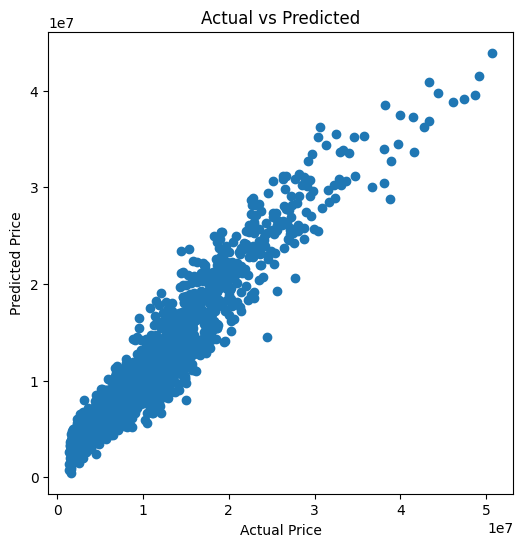

Actual: 4,974,421 | Predicted: 6,299,376
Actual: 5,558,515 | Predicted: 7,413,988
Actual: 14,959,629 | Predicted: 9,786,400
Actual: 1,562,114 | Predicted: 2,048,385
Actual: 3,745,098 | Predicted: 3,647,214


In [ ]:
# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.initializers import GlorotUniform, HeNormal
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping


# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("house_price_dataset_india_12k.csv")
df.columns = df.columns.str.strip()
df = df.drop(columns=["House_ID", "Price_per_sqft_INR"], errors="ignore")

X = df.drop("Market_Price_INR", axis=1)
y = df["Market_Price_INR"]


# =========================
# 3. PREPROCESSING
# =========================
categorical_nominal = ["City", "Furnishing"]
categorical_ordinal = ["Locality_Tier"]

locality_map = {"Budget": 0, "Mid": 1, "Premium": 2}
X["Locality_Tier"] = X["Locality_Tier"].map(locality_map)

numerical_cols = [col for col in X.columns if col not in categorical_nominal + categorical_ordinal]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_nominal)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Scale target
y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test = y_scaler.transform(y_test.values.reshape(-1,1))

os.makedirs("model", exist_ok=True)
joblib.dump(preprocessor, "model/scaler.pkl")
joblib.dump(y_scaler, "model/y_scaler.pkl")


# =========================
# 4. MODEL BUILDER
# =========================
def build_model(optimizer_name="adam", init_type="he", regularizer_type=None,
                use_bn=True, dropout_rate=0.3):

    initializer = HeNormal() if init_type == "he" else GlorotUniform()

    reg = None
    if regularizer_type == "l1":
        reg = l1(0.001)
    elif regularizer_type == "l2":
        reg = l2(0.001)

    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))

    model.add(Dense(128, kernel_initializer=initializer, kernel_regularizer=reg))
    if use_bn:
        model.add(BatchNormalization())
    model.add(tf.keras.layers.ReLU())
    model.add(Dropout(dropout_rate))

    model.add(Dense(64, kernel_initializer=initializer, kernel_regularizer=reg))
    if use_bn:
        model.add(BatchNormalization())
    model.add(tf.keras.layers.ReLU())

    model.add(Dense(32, kernel_initializer=initializer))
    model.add(tf.keras.layers.ReLU())

    model.add(Dense(1, activation='linear'))

    if optimizer_name == "sgd":
        optimizer = SGD(learning_rate=0.0001, clipnorm=1.0)
    elif optimizer_name == "rmsprop":
        optimizer = RMSprop(learning_rate=0.0005, clipnorm=1.0)
    else:
        optimizer = Adam(learning_rate=0.001, clipnorm=1.0)

    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

    return model


# =========================
# 5. CALLBACKS
# =========================
def lr_schedule(epoch, lr):
    if epoch > 15:
        return lr * 0.5
    return lr

early_stop = EarlyStopping(patience=5, restore_best_weights=True)


# =========================
# 6. TRAIN FUNCTION
# =========================
def train_model(config):
    model = build_model(**config)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=32,
        verbose=0,
        callbacks=[LearningRateScheduler(lr_schedule), early_stop]
    )

    return model, history


# =========================
# 7. EXPERIMENT MATRIX
# =========================
experiments = [
    # Optimizer comparison
    {"optimizer_name": "sgd", "init_type": "he", "regularizer_type": None},
    {"optimizer_name": "adam", "init_type": "he", "regularizer_type": None},
    {"optimizer_name": "rmsprop", "init_type": "he", "regularizer_type": None},

    # Initialization comparison
    {"optimizer_name": "adam", "init_type": "he"},
    {"optimizer_name": "adam", "init_type": "xavier"},

    # Regularization comparison
    {"optimizer_name": "adam", "init_type": "he", "regularizer_type": "l1"},
    {"optimizer_name": "adam", "init_type": "he", "regularizer_type": "l2"},
    {"optimizer_name": "adam", "init_type": "he", "dropout_rate": 0.5},
]


# =========================
# 8. RUN EXPERIMENTS
# =========================
results = []

plt.figure(figsize=(10,6))

for i, config in enumerate(experiments):
    print("Running:", config)

    model, history = train_model(config)

    y_pred_scaled = model.predict(X_test)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)
    y_test_actual = y_scaler.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    mae = mean_absolute_error(y_test_actual, y_pred)
    r2 = r2_score(y_test_actual, y_pred)

    results.append({
        "config": str(config),
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    # Plot convergence
    label = f"{config['optimizer_name']} | {config.get('init_type','')} | {config.get('regularizer_type','none')}"
    plt.plot(history.history["val_loss"], label=label)

plt.title("Optimizer & Config Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.savefig("optimizer_comparison.png")
plt.show()


# =========================
# 9. SAVE RESULTS TABLE
# =========================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE")

print("\n=== FINAL RESULTS ===")
print(results_df)

results_df.to_csv("experiment_results.csv", index=False)


# =========================
# 10. BEST MODEL
# =========================
best_config = eval(results_df.iloc[0]["config"])
print("\nBest Config:", best_config)

best_model, _ = train_model(best_config)
best_model.save("model/best_model.keras")


# =========================
# 11. FINAL EVALUATION PLOT
# =========================
y_pred_scaled = best_model.predict(X_test)
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_test_actual = y_scaler.inverse_transform(y_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.savefig("actual_vs_predicted.png")
plt.show()


# =========================
# 12. SAMPLE PREDICTIONS
# =========================
for i in range(5):
    print(f"Actual: {y_test_actual[i][0]:,.0f} | Predicted: {y_pred[i][0]:,.0f}")